## Instalar liberías necesarias

In [ ]:
!pip install ultralytics roboflow

  Using cached ultralytics-8.4.77-py3-none-any.whl.metadata (41 kB)
  Using cached ultralytics_thop-2.0.20-py3-none-any.whl.metadata (14 kB)
Using cached ultralytics-8.4.77-py3-none-any.whl (1.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 134.9 MB/s eta 0:00:00
Using cached ultralytics_thop-2.0.20-py3-none-any.whl (28 kB)
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully 

## Descomprimir archivo con conjunto de datos del roboflow


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="QYcAq5SY5FQozQlkU5Vy")
project = rf.workspace("workspace-hoc3o").project("bone-detection-pro")
version = project.version(6)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


## Entrenar modelo

In [ ]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import cv2 as cv
import torch
import os

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU disponible. Usando:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("No hay GPU disponible. Usando CPU.")

GPU disponible. Usando: Tesla T4


In [ ]:
# Cargar un modelo YOLO26n preentrenado
model = YOLO('/content/yolo26n.pt')

# RECORDAR UTILIZAR LA GPU CON device=0
train_results = model.train(
    data="/content/Bone-Detection-PRO+-6/data.yaml",   # Ruta al archivo de configuración del conjunto de datos
    epochs=100,          # Número de épocas de entrenamiento
    imgsz=640,          # Tamaño de las imágenes durante el entrenamiento
    device=0,       # Usar GPU si está disponible
)

Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Bone-Detection-PRO+-6/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False,

In [ ]:
# Evaluar el rendimiento del modelo en el conjunto de validación
model = YOLO('/content/runs/detect/train-2/weights/best.pt')

metrics = model.val(
    device=0,
    plots=True,
    visualize=True
)

Ultralytics 8.4.77 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 964.9±396.8 MB/s, size: 28.1 KB)
val: Scanning /content/Bone-Detection-PRO+-6/valid/labels.cache... 170 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 170/170 64.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.0s/it 11.0s
                   all        170        306      0.555      0.513      0.468      0.201
             Conminuta         82        154      0.487      0.539      0.441      0.197
                Simple         84        152      0.622      0.487      0.494      0.204
Speed: 4.4ms preprocess, 6.2ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to /content/runs/detect/val


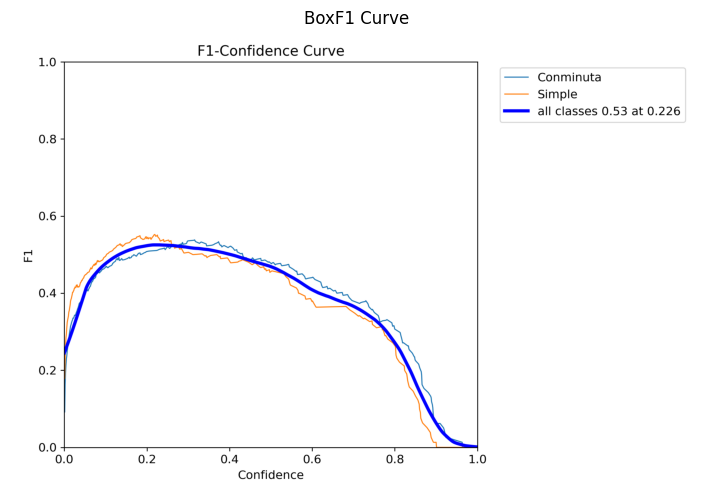

In [ ]:
image_path = '/content/runs/detect/val/BoxF1_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('BoxF1 Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

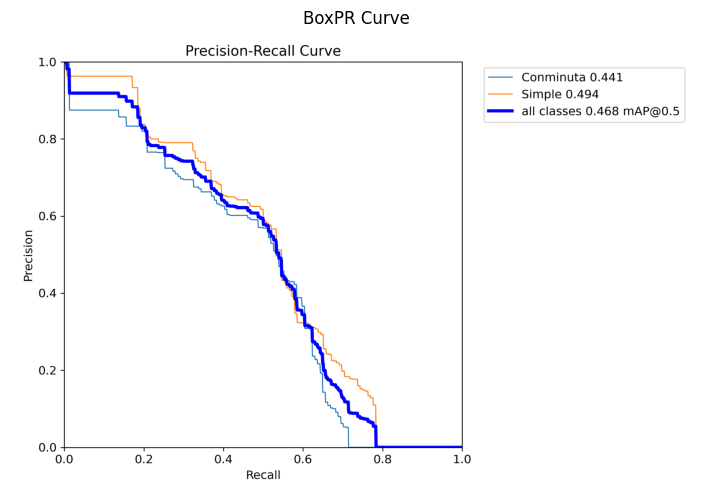

In [ ]:
image_path = '/content/runs/detect/val/BoxPR_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('BoxPR Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

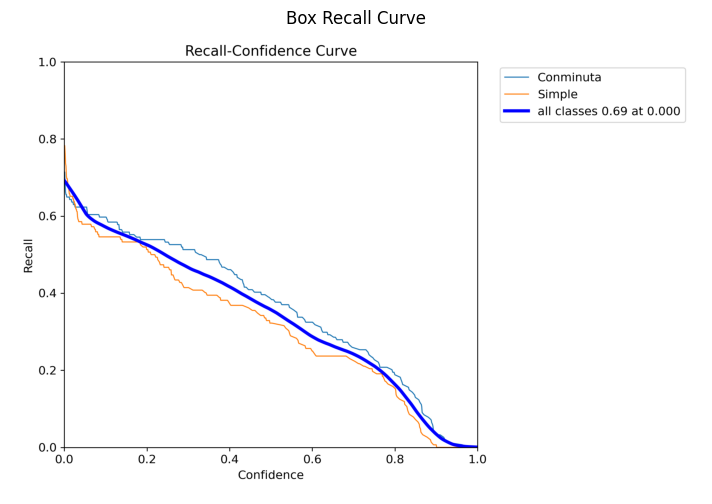

In [ ]:
image_path = '/content/runs/detect/val/BoxR_curve.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title('Box Recall Curve')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

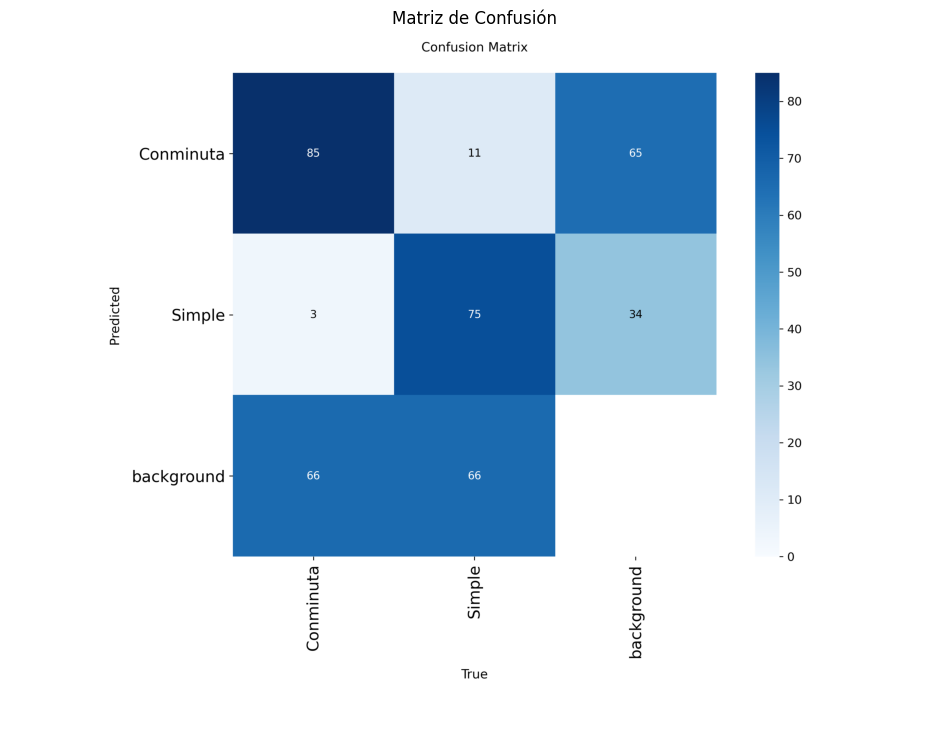

In [ ]:
image_path = '/content/runs/detect/val/confusion_matrix.png'

if os.path.exists(image_path):
    img = mpimg.imread(image_path)
    plt.figure(figsize=(12, 12))
    plt.imshow(img)
    plt.title('Matriz de Confusión')
    plt.axis('off')
    plt.show()
else:
    print(f"Error: No se encontró la imagen en la ruta: {image_path}")

# Predicciones YOLO + OpenCV


image 1/1 /content/588_Simple Bone Fracture.jpg: 640x608 2 Simples, 18.7ms
Speed: 4.6ms preprocess, 18.7ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 608)
Bounding Box: tensor([[262.6788, 223.3574, 319.7966, 279.8009]], device='cuda:0'), Confidence: tensor([0.8236], device='cuda:0'), Class: Simple
Bounding Box: tensor([[ 91.6549, 114.5350, 143.1218, 170.2798]], device='cuda:0'), Confidence: tensor([0.6101], device='cuda:0'), Class: Simple


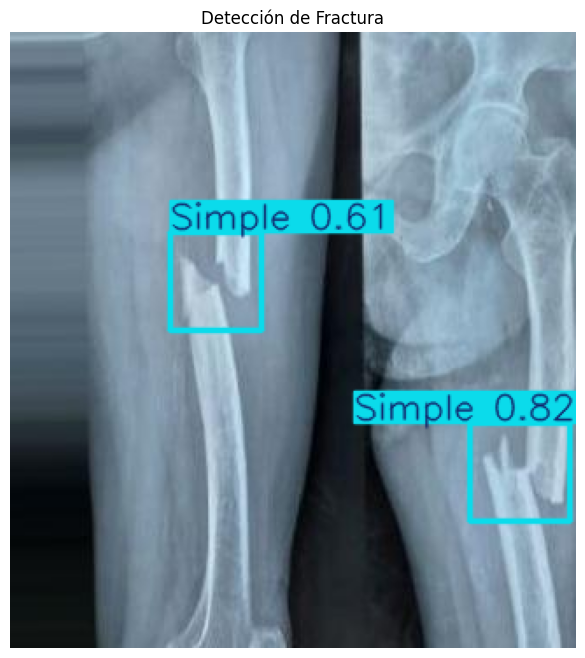

In [ ]:
# Cargar modelo YOLO pre-entrenado
model = YOLO('/content/runs/detect/train-2/weights/best.pt')

# Ruta de la imagen
image_path = '/content/588_Simple Bone Fracture.jpg'

# Realizar la detección
results = model(image_path)

# print("Resultados: ", results)

# Mostrar resultados
for r in results:
    # Acceder a las cajas delimitadoras y sus puntuaciones de confianza
    boxes = r.boxes
    for box in boxes:
        # box.xyxy contiene las coordenadas [x1, y1, x2, y2]
        # box.conf contiene la puntuación de confianza
        # box.cls contiene el índice de la clase
        print(f"Bounding Box: {box.xyxy}, Confidence: {box.conf}, Class: {model.names[int(box.cls)]}")

    im_array = r.plot()  # Imagen con cajas dibujadas (BGR)

    # Convertir de BGR (OpenCV) a RGB (para matplotlib)
    im_rgb = cv.cvtColor(im_array, cv.COLOR_BGR2RGB)

    # Mostrar con matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title('Detección de Fractura')
    plt.show()

    # Guardar el resultado
    cv.imwrite('resultado_imagen.jpg', im_array)


image 1/1 /content/image1_70.png: 640x640 1 Conminuta, 11.8ms
Speed: 2.9ms preprocess, 11.8ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Bounding Box: tensor([[183.2054, 118.4255, 335.8767, 221.7655]], device='cuda:0'), Confidence: tensor([0.6362], device='cuda:0'), Class: Conminuta


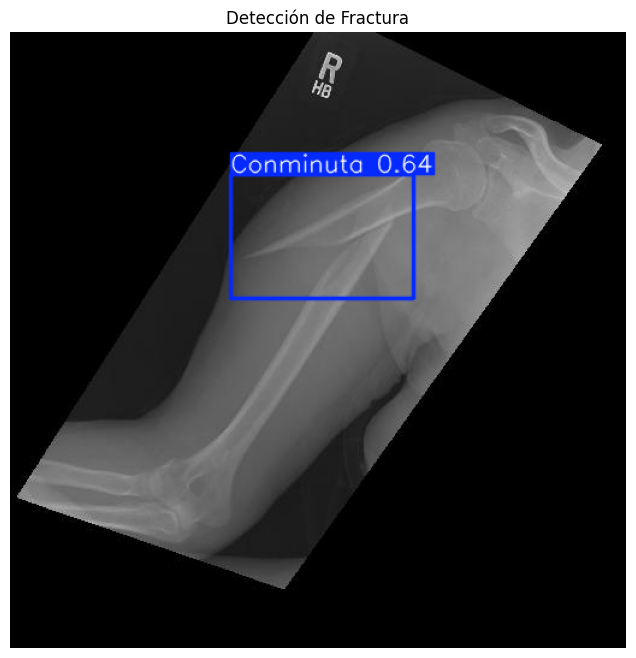

In [ ]:
# Cargar modelo YOLO pre-entrenado
model = YOLO('/content/runs/detect/train-2/weights/best.pt')

# Ruta de la imagen
image_path = '/content/image1_70.png'

# Realizar la detección
results = model(image_path)

# print("Resultados: ", results)

# Mostrar resultados
for r in results:
    # Acceder a las cajas delimitadoras y sus puntuaciones de confianza
    boxes = r.boxes
    for box in boxes:
        # box.xyxy contiene las coordenadas [x1, y1, x2, y2]
        # box.conf contiene la puntuación de confianza
        # box.cls contiene el índice de la clase
        print(f"Bounding Box: {box.xyxy}, Confidence: {box.conf}, Class: {model.names[int(box.cls)]}")

    im_array = r.plot()  # Imagen con cajas dibujadas (BGR)

    # Convertir de BGR (OpenCV) a RGB (para matplotlib)
    im_rgb = cv.cvtColor(im_array, cv.COLOR_BGR2RGB)

    # Mostrar con matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(im_rgb)
    plt.axis('off')
    plt.title('Detección de Fractura')
    plt.show()

    # Guardar el resultado
    cv.imwrite('resultado_imagen_error.jpg', im_array)